In [33]:
# Install all required libraries
!pip install yfinance pandas numpy matplotlib statsmodels pmdarima prophet tensorflow scikit-learn arch -q

In [34]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import pmdarima as pm

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


In [35]:
# Task 1: Fetch stock data from Yahoo Finance
tickers = [
    'HDFCBANK.NS',   # Banking
    'INFY.NS',       # IT
    'SUNPHARMA.NS',  # Pharma
    'RELIANCE.NS',   # Energy
    'MARUTI.NS'      # Auto
]

from datetime import date

today = "2026-05-15"  # end is exclusive in yfinance, so this fetches up to May 14
data = yf.download(tickers, start="2021-01-01", end=today)["Close"]

print(f'Dataset shape: {data.shape}')
print(f'Date range: {data.index[0].date()} → {data.index[-1].date()}')
print(f'\nMissing values:\n{data.isnull().sum()}')
print(f'\nFirst 3 rows:\n{data.head(3)}')

[*********************100%***********************]  5 of 5 completed

Dataset shape: (1326, 5)
Date range: 2021-01-01 → 2026-05-14

Missing values:
Ticker
HDFCBANK.NS     0
INFY.NS         0
MARUTI.NS       0
RELIANCE.NS     0
SUNPHARMA.NS    0
dtype: int64

First 3 rows:
Ticker      HDFCBANK.NS      INFY.NS    MARUTI.NS  RELIANCE.NS  SUNPHARMA.NS
Date                                                                        
2021-01-01   674.886414  1109.599976  7371.631836   901.194641    562.592957
2021-01-04   670.600342  1134.072510  7382.174805   902.713623    570.282776
2021-01-05   675.667786  1138.958618  7337.271973   891.491150    569.386475


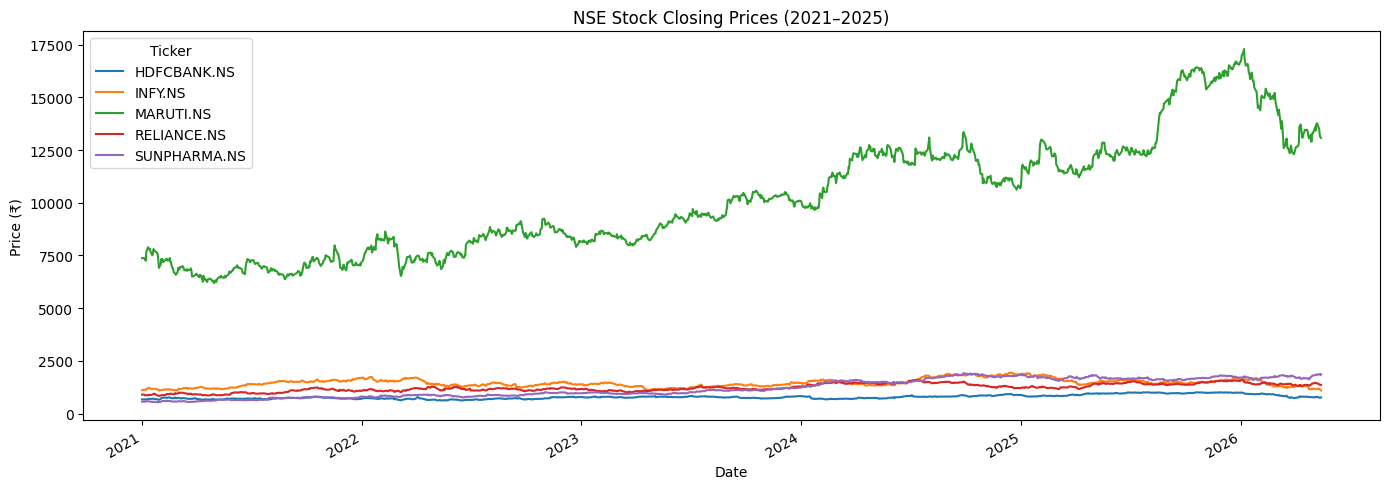

In [36]:
# Raw price plot — shows scale distortion (Maruti dominates)
data.plot(figsize=(14, 5), title='NSE Stock Closing Prices (2021–2025)')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

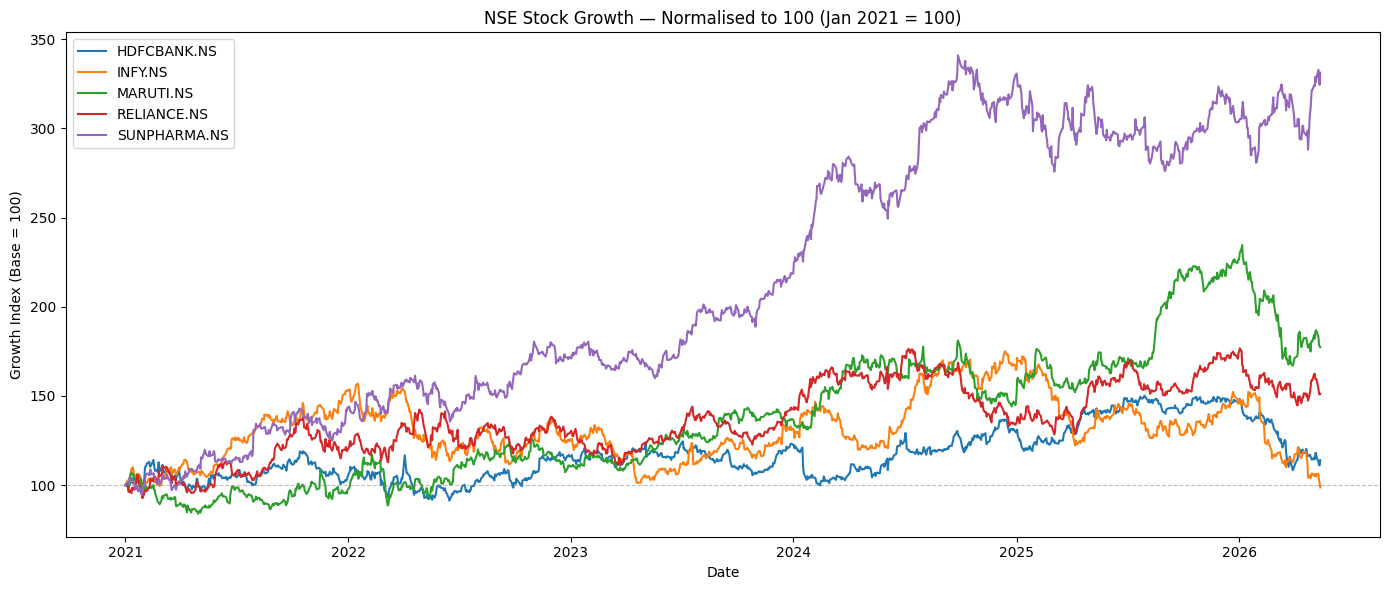

=== Total % Gain (Jan 2021 → Dec 2025) ===
HDFCBANK.NS         : +14.0%
INFY.NS             : -1.3%
MARUTI.NS           : +77.4%
RELIANCE.NS         : +51.1%
SUNPHARMA.NS        : +231.2%


In [37]:
# Normalized growth chart — fair comparison (Base = 100 on Jan 1 2021)
normalized = (data / data.iloc[0]) * 100

plt.figure(figsize=(14, 6))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)

plt.title('NSE Stock Growth — Normalised to 100 (Jan 2021 = 100)')
plt.xlabel('Date')
plt.ylabel('Growth Index (Base = 100)')
plt.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Print actual % gain per stock
print('=== Total % Gain (Jan 2021 → Dec 2025) ===')
for col in data.columns:
    gain = ((data[col].iloc[-1] - data[col].iloc[0]) / data[col].iloc[0]) * 100
    print(f'{col:20s}: {gain:+.1f}%')

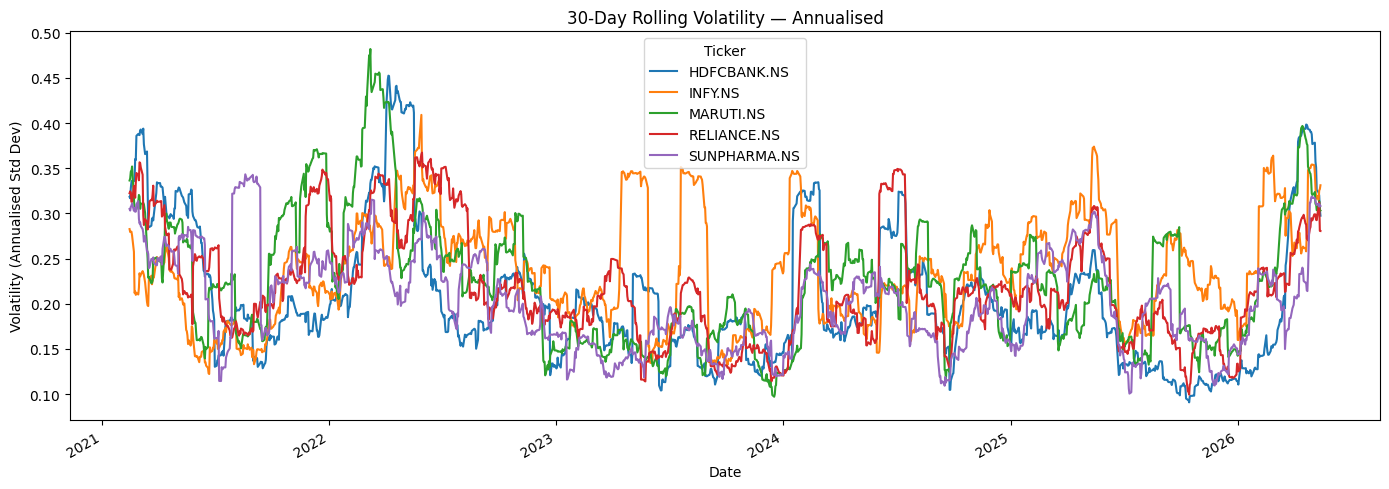

=== Average Annualised Volatility (2021–2025) ===
SUNPHARMA.NS        : 20.24%
HDFCBANK.NS         : 20.34%
RELIANCE.NS         : 21.98%
MARUTI.NS           : 22.39%
INFY.NS             : 23.66%


In [38]:
# Rolling volatility — Task 1 data-driven justification
log_returns = np.log(data / data.shift(1))
rolling_vol = log_returns.rolling(window=30).std() * np.sqrt(252)

rolling_vol.plot(figsize=(14, 5), title='30-Day Rolling Volatility — Annualised')
plt.xlabel('Date')
plt.ylabel('Volatility (Annualised Std Dev)')
plt.tight_layout()
plt.show()

print('=== Average Annualised Volatility (2021–2025) ===')
avg_vol = rolling_vol.mean().sort_values()
for ticker, vol in avg_vol.items():
    print(f'{ticker:20s}: {vol:.2%}')

In [39]:
# Step 1: Forward fill missing values
data.ffill(inplace=True)

# Step 2: Train/Test split
split_date = (pd.Timestamp.now() - pd.DateOffset(months=1)).strftime('%Y-%m-%d')

train = data[data.index < split_date]
test  = data[data.index >= split_date]

print(f'Train size : {train.shape}  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test size  : {test.shape}  ({test.index[0].date()} → {test.index[-1].date()})')

Train size : (1304, 5)  (2021-01-01 → 2026-04-13)
Test size  : (22, 5)  (2026-04-15 → 2026-05-14)


In [40]:
# Step 3: ADF Test — original price series
# ADF tests if a series is stationary (p < 0.05 = stationary)
# Stock prices are almost always non-stationary (they trend)

def adf_test(series, name):
    result = adfuller(series.dropna())
    p_value = result[1]
    print(f'{name:20s} | ADF Stat: {result[0]:8.3f} | p-value: {p_value:.4f} | {"✅ Stationary" if p_value < 0.05 else "❌ Non-Stationary"}')

print('=' * 65)
print('ADF TEST — ORIGINAL PRICE SERIES')
print('=' * 65)
for col in train.columns:
    adf_test(train[col], col)

ADF TEST — ORIGINAL PRICE SERIES
HDFCBANK.NS          | ADF Stat:   -1.852 | p-value: 0.3552 | ❌ Non-Stationary
INFY.NS              | ADF Stat:   -2.459 | p-value: 0.1258 | ❌ Non-Stationary
MARUTI.NS            | ADF Stat:   -1.055 | p-value: 0.7328 | ❌ Non-Stationary
RELIANCE.NS          | ADF Stat:   -2.202 | p-value: 0.2054 | ❌ Non-Stationary
SUNPHARMA.NS         | ADF Stat:   -1.159 | p-value: 0.6909 | ❌ Non-Stationary


In [41]:
# Step 4: First Differencing
# Differencing = today's price minus yesterday's price
# Removes trend → makes series stationary
# Formula: X't = Xt - Xt-1

train_diff = train.diff().dropna()

print('=' * 65)
print('ADF TEST — AFTER FIRST DIFFERENCING')
print('=' * 65)
for col in train_diff.columns:
    adf_test(train_diff[col], col)

ADF TEST — AFTER FIRST DIFFERENCING
HDFCBANK.NS          | ADF Stat:  -13.995 | p-value: 0.0000 | ✅ Stationary
INFY.NS              | ADF Stat:  -35.039 | p-value: 0.0000 | ✅ Stationary
MARUTI.NS            | ADF Stat:  -32.866 | p-value: 0.0000 | ✅ Stationary
RELIANCE.NS          | ADF Stat:  -21.946 | p-value: 0.0000 | ✅ Stationary
SUNPHARMA.NS         | ADF Stat:  -10.741 | p-value: 0.0000 | ✅ Stationary


In [42]:
# Step 5: MinMaxScaling for LSTM
# Scales all prices to [0, 1] range
# Formula: X_scaled = (X - X_min) / (X_max - X_min)
# scaler_dict saves each scaler to reverse predictions back to ₹ later

scaler_dict = {}
train_scaled = pd.DataFrame(index=train.index)

for col in train.columns:
    scaler = MinMaxScaler()
    train_scaled[col] = scaler.fit_transform(train[[col]]).flatten()
    scaler_dict[col] = scaler  # save to reverse later

print('=== Scaled Training Data (first 3 rows) ===')
print(train_scaled.head(3).round(4))
print(f'\nMin: {train_scaled.min().round(4).to_dict()}')
print(f'Max: {train_scaled.max().round(4).to_dict()}')

=== Scaled Training Data (first 3 rows) ===
            HDFCBANK.NS  INFY.NS  MARUTI.NS  RELIANCE.NS  SUNPHARMA.NS
Date                                                                  
2021-01-01       0.1472   0.0221     0.1066       0.0872        0.0217
2021-01-04       0.1364   0.0509     0.1076       0.0892        0.0273
2021-01-05       0.1492   0.0566     0.1036       0.0744        0.0266

Min: {'HDFCBANK.NS': 0.0, 'INFY.NS': 0.0, 'MARUTI.NS': 0.0, 'RELIANCE.NS': 0.0, 'SUNPHARMA.NS': 0.0}
Max: {'HDFCBANK.NS': 1.0, 'INFY.NS': 1.0, 'MARUTI.NS': 1.0, 'RELIANCE.NS': 1.0, 'SUNPHARMA.NS': 1.0}


In [43]:
# ARIMA Step 1: Find best (p, d, q) for each stock using AIC
# auto_arima tries combinations and picks lowest AIC
# AIC = 2k - 2ln(L): rewards accuracy, penalises complexity

best_models = {}

for stock in train.columns:
    print(f'Finding best ARIMA for {stock}...')
    model = pm.auto_arima(
        train[stock],
        d=1,                          # fixed from ADF test
        start_p=0, max_p=3,           # AR order range
        start_q=0, max_q=3,           # MA order range
        seasonal=False,               # no seasonality
        information_criterion='aic',  # select by AIC
        stepwise=True,                # smart search
        verbose=False
    )
    best_models[stock] = model
    print(f'  ✅ Best: ARIMA{model.order} | AIC: {model.aic():.2f}')

print('\n=== ARIMA PARAMETER SUMMARY ===')
for stock, model in best_models.items():
    print(f'{stock:20s} → ARIMA{model.order} | AIC: {model.aic():.2f}')

Finding best ARIMA for HDFCBANK.NS...
  ✅ Best: ARIMA(0, 1, 0) | AIC: 9817.94
Finding best ARIMA for INFY.NS...
  ✅ Best: ARIMA(0, 1, 0) | AIC: 11832.59
Finding best ARIMA for MARUTI.NS...
  ✅ Best: ARIMA(0, 1, 1) | AIC: 16766.91
Finding best ARIMA for RELIANCE.NS...
  ✅ Best: ARIMA(0, 1, 0) | AIC: 11167.76
Finding best ARIMA for SUNPHARMA.NS...
  ✅ Best: ARIMA(0, 1, 1) | AIC: 10917.70

=== ARIMA PARAMETER SUMMARY ===
HDFCBANK.NS          → ARIMA(0, 1, 0) | AIC: 9817.94
INFY.NS              → ARIMA(0, 1, 0) | AIC: 11832.59
MARUTI.NS            → ARIMA(0, 1, 1) | AIC: 16766.91
RELIANCE.NS          → ARIMA(0, 1, 0) | AIC: 11167.76
SUNPHARMA.NS         → ARIMA(0, 1, 1) | AIC: 10917.70


In [44]:
# ARIMA Step 2: Walk-Forward Validation
# At each test day: retrain on all history so far, predict next day
# This is the correct way — avoids overfitting on test data

def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

arima_results = {}

for stock in train.columns:
    print(f'Walk-forward forecasting: {stock}...')
    history = list(train[stock])
    predictions = []

    for t in range(len(test)):
        model = pm.auto_arima(
            history, d=1,
            start_p=0, max_p=3,
            start_q=0, max_q=3,
            seasonal=False,
            stepwise=True, verbose=False
        )
        yhat = model.predict(n_periods=1)[0]
        predictions.append(yhat)
        history.append(test[stock].iloc[t])  # add real value for next step

    actual = test[stock].values
    predictions = np.array(predictions)

    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mape_score = mape(actual, predictions)
    dir_acc = np.mean(
        np.sign(np.diff(actual)) == np.sign(np.diff(predictions))
    ) * 100

    arima_results[stock] = {
        'forecast': predictions,
        'rmse': rmse,
        'mape': mape_score,
        'dir_acc': dir_acc
    }
    print(f'  ✅ RMSE: {rmse:.2f} | MAPE: {mape_score:.2f}% | Dir Acc: {dir_acc:.1f}%')

Walk-forward forecasting: HDFCBANK.NS...
  ✅ RMSE: 11.81 | MAPE: 1.23% | Dir Acc: 38.1%
Walk-forward forecasting: INFY.NS...
  ✅ RMSE: 26.42 | MAPE: 1.58% | Dir Acc: 42.9%
Walk-forward forecasting: MARUTI.NS...
  ✅ RMSE: 190.30 | MAPE: 1.09% | Dir Acc: 47.6%
Walk-forward forecasting: RELIANCE.NS...
  ✅ RMSE: 21.28 | MAPE: 1.15% | Dir Acc: 52.4%
Walk-forward forecasting: SUNPHARMA.NS...
  ✅ RMSE: 33.49 | MAPE: 1.35% | Dir Acc: 47.6%


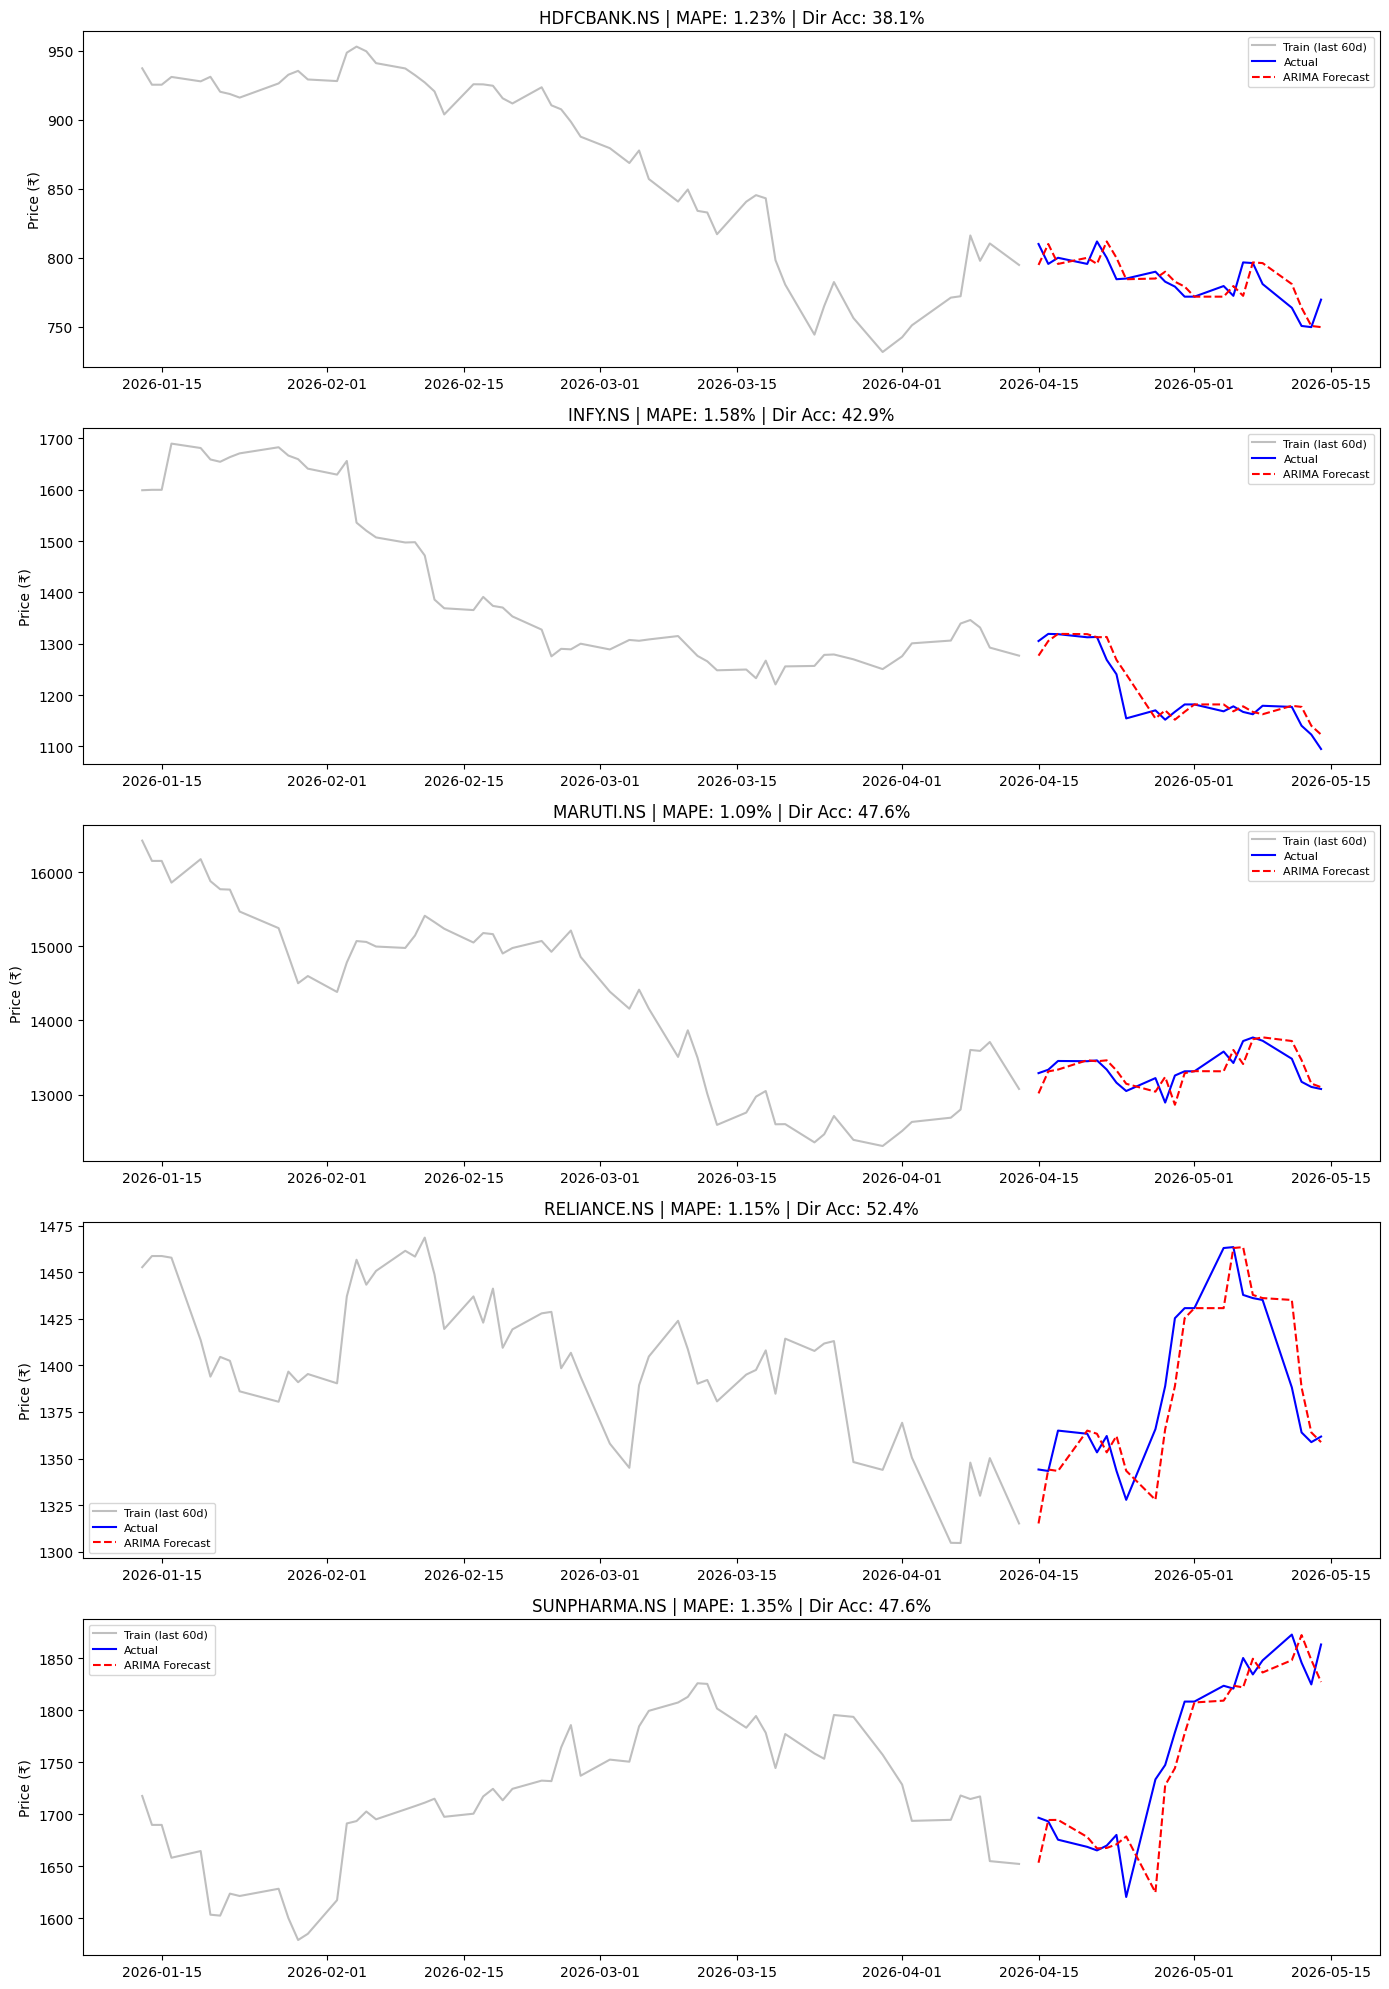

📊 Plot saved as arima_forecasts.png


In [45]:
# ARIMA Step 3: Plot Actual vs Predicted
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for idx, stock in enumerate(train.columns):
    ax = axes[idx]
    ax.plot(train[stock].iloc[-60:], label='Train (last 60d)', color='gray', alpha=0.5)
    ax.plot(test[stock], label='Actual', color='blue')
    ax.plot(test.index, arima_results[stock]['forecast'],
            label='ARIMA Forecast', color='red', linestyle='--')
    ax.set_title(f"{stock} | MAPE: {arima_results[stock]['mape']:.2f}% | "
                 f"Dir Acc: {arima_results[stock]['dir_acc']:.1f}%")
    ax.legend(fontsize=8)
    ax.set_ylabel('Price (₹)')

plt.tight_layout()
plt.savefig('arima_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Plot saved as arima_forecasts.png')

In [46]:
from prophet import Prophet

prophet_results = {}

for stock in train.columns:
    print(f'Fitting Prophet for {stock}...')

    # Prophet needs columns named 'ds' (date) and 'y' (value)
    df_prophet = pd.DataFrame({
        'ds': train.index,
        'y': train[stock].values
    })

    # Fit model
    model = Prophet(
        daily_seasonality=False,   # stock data — no intraday pattern
        weekly_seasonality=True,   # markets have weekly cycles
        yearly_seasonality=True,   # annual patterns
        changepoint_prior_scale=0.05  # controls trend flexibility
    )
    model.fit(df_prophet)

    # Create future dataframe for test period
    future = pd.DataFrame({'ds': test.index})
    forecast = model.predict(future)
    predictions = forecast['yhat'].values
    actual = test[stock].values

    # Metrics
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mape_score = mape(actual, predictions)
    dir_acc = np.mean(
        np.sign(np.diff(actual)) == np.sign(np.diff(predictions))
    ) * 100

    prophet_results[stock] = {
        'forecast': predictions,
        'rmse': rmse,
        'mape': mape_score,
        'dir_acc': dir_acc
    }
    print(f'  ✅ RMSE: {rmse:.2f} | MAPE: {mape_score:.2f}% | Dir Acc: {dir_acc:.1f}%')

Fitting Prophet for HDFCBANK.NS...
  ✅ RMSE: 122.48 | MAPE: 15.56% | Dir Acc: 38.1%
Fitting Prophet for INFY.NS...
  ✅ RMSE: 56.05 | MAPE: 3.28% | Dir Acc: 47.6%
Fitting Prophet for MARUTI.NS...
  ✅ RMSE: 2345.42 | MAPE: 17.49% | Dir Acc: 42.9%
Fitting Prophet for RELIANCE.NS...
  ✅ RMSE: 122.18 | MAPE: 8.54% | Dir Acc: 47.6%
Fitting Prophet for SUNPHARMA.NS...
  ✅ RMSE: 102.75 | MAPE: 4.87% | Dir Acc: 42.9%


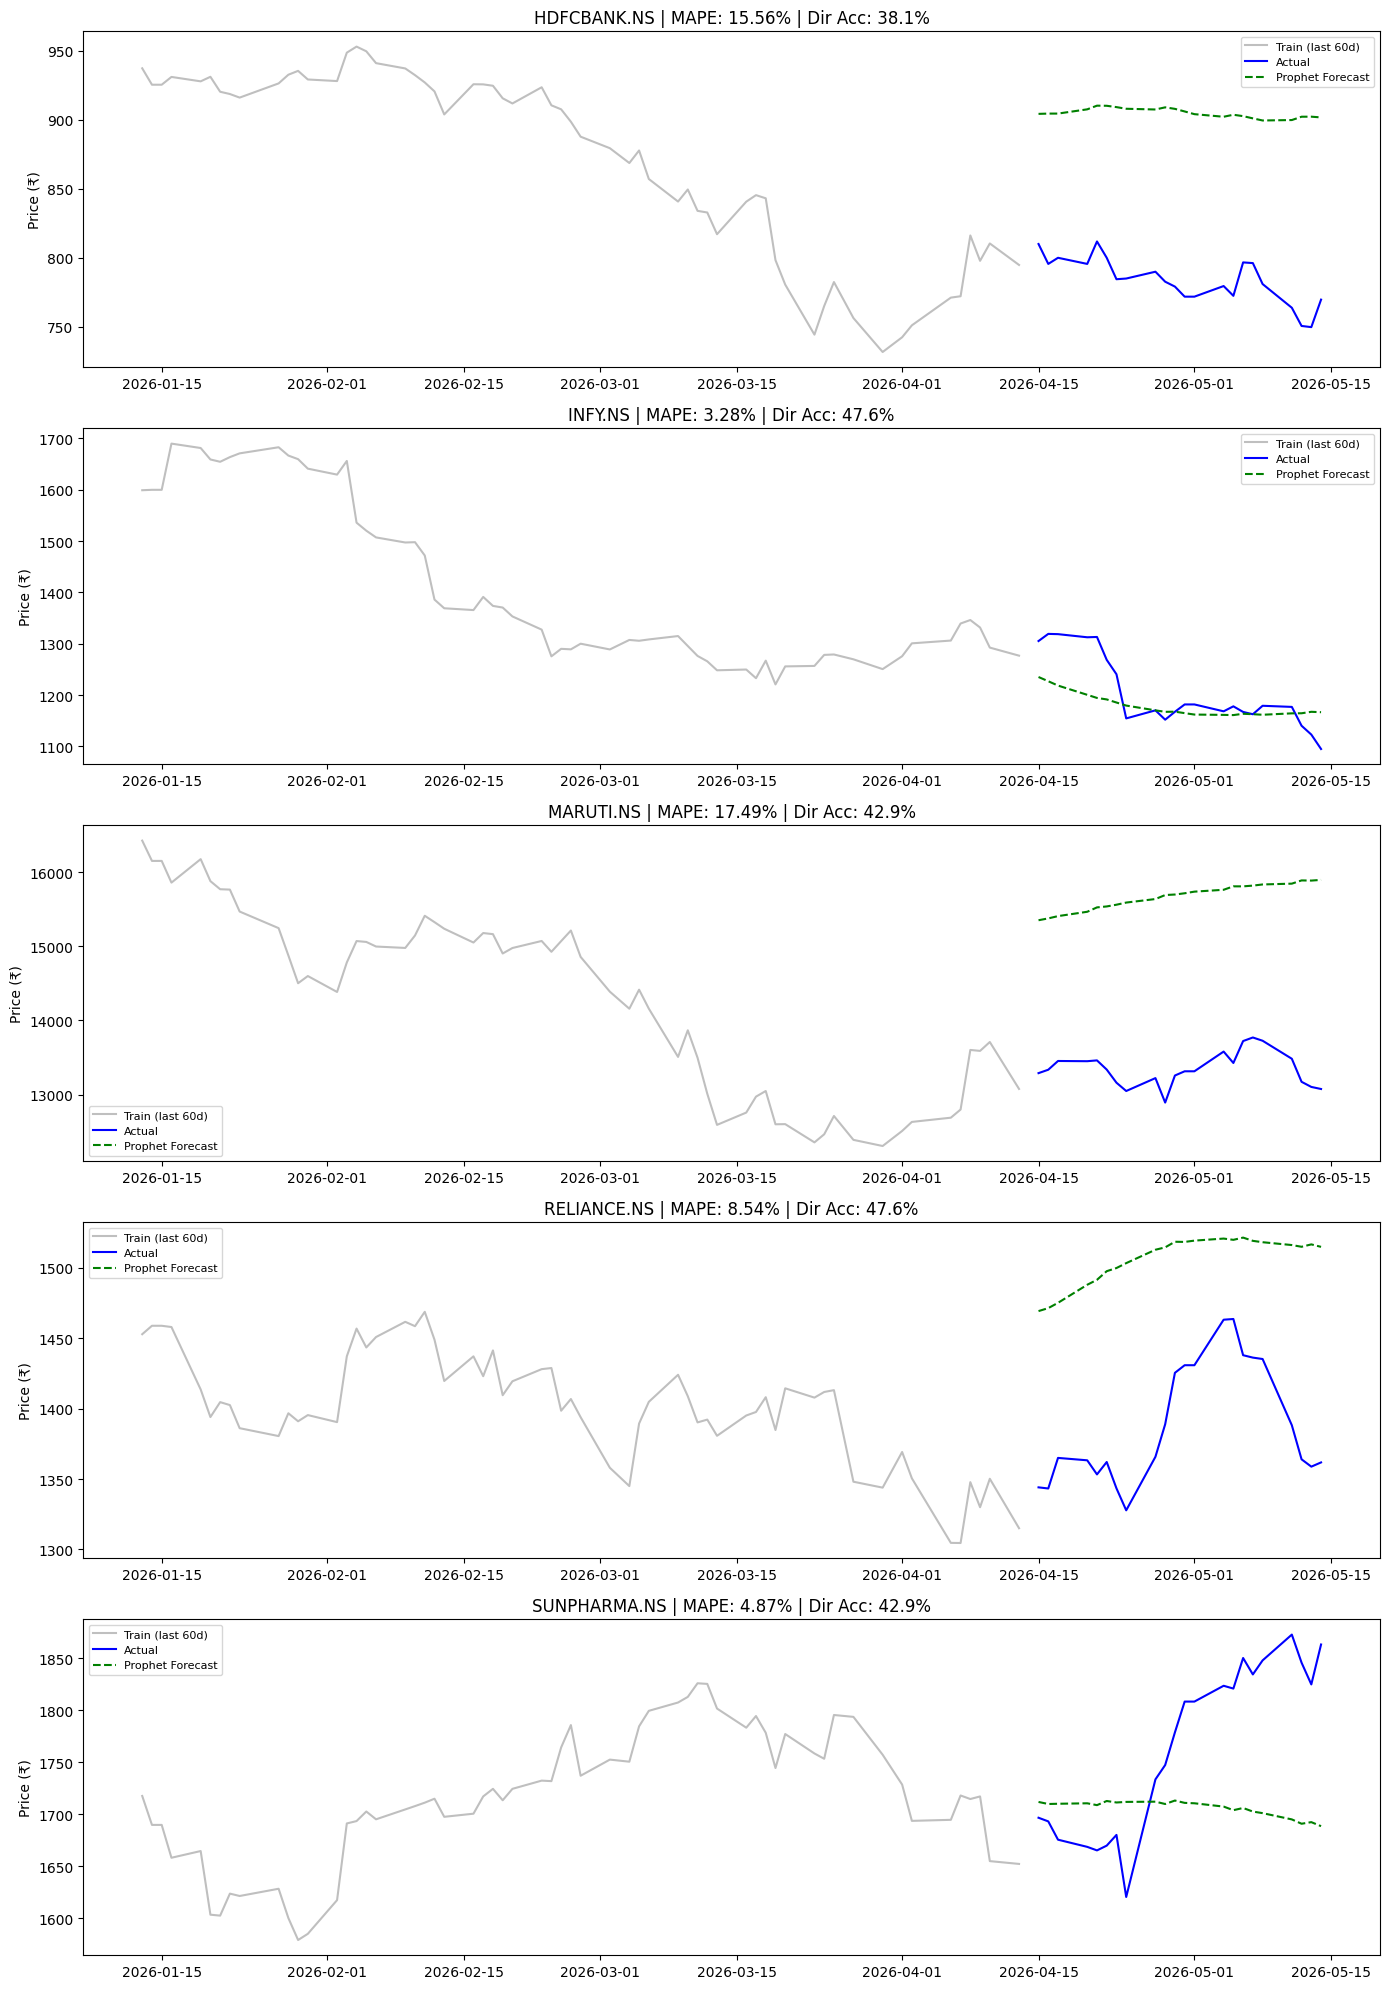

In [47]:
# Prophet: Plot Actual vs Predicted
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for idx, stock in enumerate(train.columns):
    ax = axes[idx]
    ax.plot(train[stock].iloc[-60:], label='Train (last 60d)', color='gray', alpha=0.5)
    ax.plot(test[stock], label='Actual', color='blue')
    ax.plot(test.index, prophet_results[stock]['forecast'],
            label='Prophet Forecast', color='green', linestyle='--')
    ax.set_title(f"{stock} | MAPE: {prophet_results[stock]['mape']:.2f}% | "
                 f"Dir Acc: {prophet_results[stock]['dir_acc']:.1f}%")
    ax.legend(fontsize=8)
    ax.set_ylabel('Price (₹)')

plt.tight_layout()
plt.savefig('prophet_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

LOOKBACK = 60  # use last 60 days to predict next day

def create_sequences(data_array, lookback):
    """Convert time series to (X, y) sequences for LSTM.
    X = window of 'lookback' days, y = next day's price"""
    X, y = [], []
    for i in range(lookback, len(data_array)):
        X.append(data_array[i-lookback:i])
        y.append(data_array[i])
    return np.array(X), np.array(y)

def build_lstm_model(lookback):
    """Build a 2-layer LSTM model."""
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(0.2),           # prevent overfitting
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1)                # output: next day's price
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_results = {}
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

for stock in train.columns:
    print(f'\nTraining LSTM for {stock}...')

    # Scale full data (train + test) using training scaler
    scaler = scaler_dict[stock]
    full_data = data[stock].values.reshape(-1, 1)
    full_scaled = scaler.transform(full_data).flatten()

    # Split scaled data
    train_len = len(train)
    train_sc = full_scaled[:train_len]
    test_sc  = full_scaled[train_len:]

    # Create sequences
    X_train, y_train = create_sequences(train_sc, LOOKBACK)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

    # Build and train
    model = build_lstm_model(LOOKBACK)
    model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    # Predict on test set
    # Use last 60 days of train + test for rolling prediction
    combined = np.concatenate([train_sc[-LOOKBACK:], test_sc])
    predictions_scaled = []
    for i in range(len(test)):
        window = combined[i:i+LOOKBACK].reshape(1, LOOKBACK, 1)
        pred = model.predict(window, verbose=0)[0][0]
        predictions_scaled.append(pred)

    # Reverse scaling to get ₹ prices
    predictions = scaler.inverse_transform(
        np.array(predictions_scaled).reshape(-1, 1)
    ).flatten()
    actual = test[stock].values

    # Metrics
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mape_score = mape(actual, predictions)
    dir_acc = np.mean(
        np.sign(np.diff(actual)) == np.sign(np.diff(predictions))
    ) * 100

    lstm_results[stock] = {
        'forecast': predictions,
        'rmse': rmse,
        'mape': mape_score,
        'dir_acc': dir_acc
    }
    print(f'  ✅ RMSE: {rmse:.2f} | MAPE: {mape_score:.2f}% | Dir Acc: {dir_acc:.1f}%')


Training LSTM for HDFCBANK.NS...
  ✅ RMSE: 13.53 | MAPE: 1.35% | Dir Acc: 38.1%

Training LSTM for INFY.NS...
  ✅ RMSE: 93.25 | MAPE: 6.78% | Dir Acc: 52.4%

Training LSTM for MARUTI.NS...
  ✅ RMSE: 267.30 | MAPE: 1.72% | Dir Acc: 42.9%

Training LSTM for RELIANCE.NS...
  ✅ RMSE: 53.01 | MAPE: 2.90% | Dir Acc: 42.9%

Training LSTM for SUNPHARMA.NS...
  ✅ RMSE: 70.66 | MAPE: 3.38% | Dir Acc: 61.9%


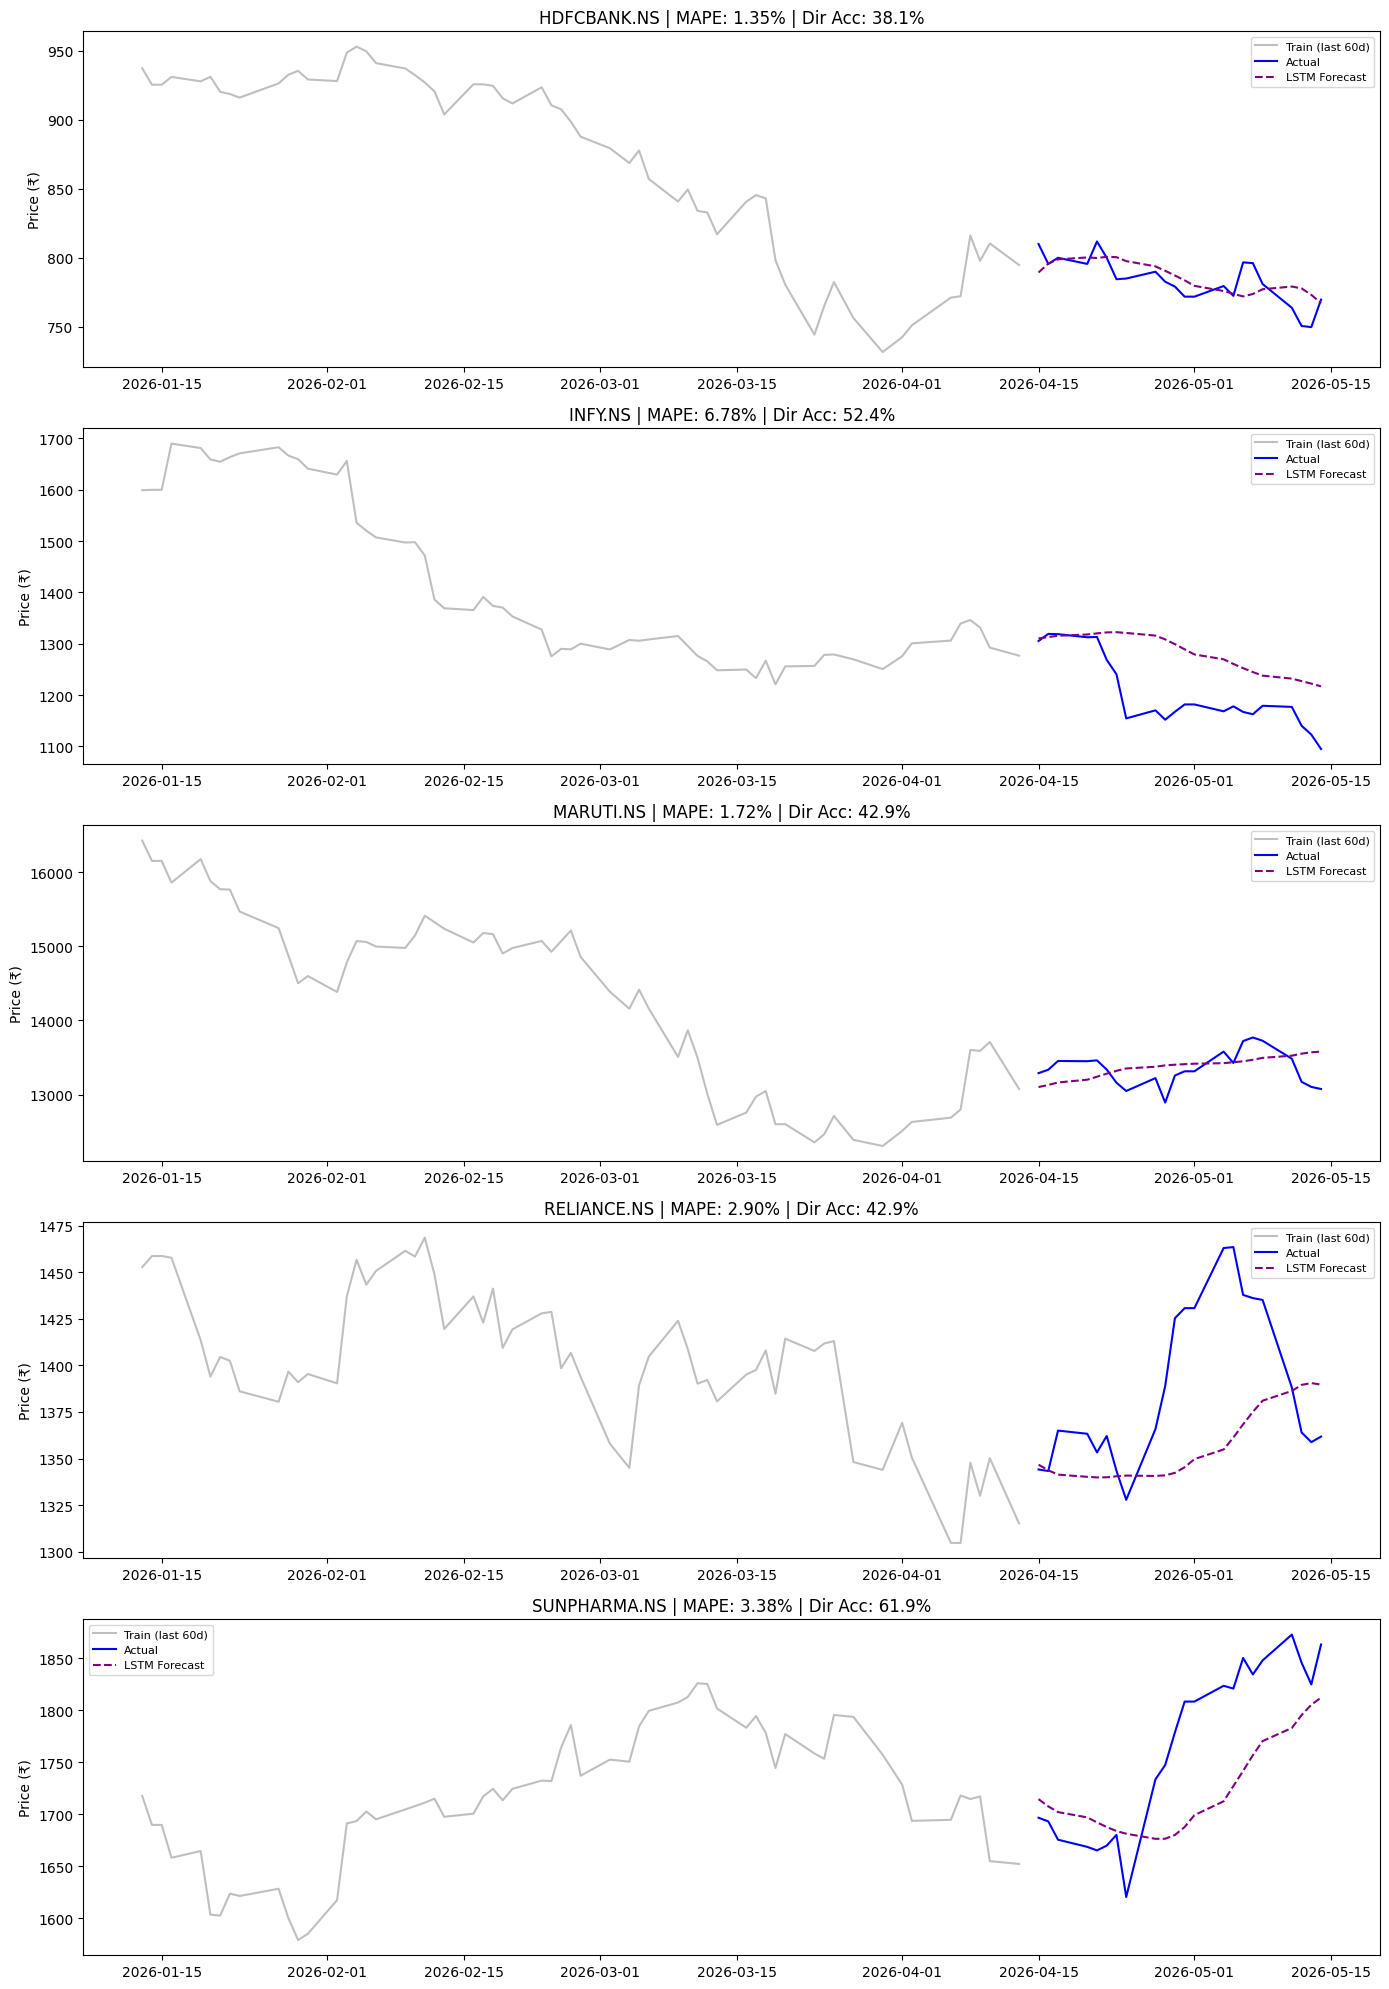

In [49]:
# LSTM: Plot Actual vs Predicted
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for idx, stock in enumerate(train.columns):
    ax = axes[idx]
    ax.plot(train[stock].iloc[-60:], label='Train (last 60d)', color='gray', alpha=0.5)
    ax.plot(test[stock], label='Actual', color='blue')
    ax.plot(test.index, lstm_results[stock]['forecast'],
            label='LSTM Forecast', color='purple', linestyle='--')
    ax.set_title(f"{stock} | MAPE: {lstm_results[stock]['mape']:.2f}% | "
                 f"Dir Acc: {lstm_results[stock]['dir_acc']:.1f}%")
    ax.legend(fontsize=8)
    ax.set_ylabel('Price (₹)')

plt.tight_layout()
plt.savefig('lstm_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
from arch import arch_model

garch_vol = {}

for stock in train.columns:
    # Compute log returns (required for GARCH)
    log_ret = np.log(train[stock] / train[stock].shift(1)).dropna() * 100

    # Fit GARCH(1,1)
    # p=1: uses 1 past squared return
    # q=1: uses 1 past variance
    garch = arch_model(log_ret, vol='Garch', p=1, q=1, dist='normal')
    result = garch.fit(disp='off')

    # Forecast 1-step ahead volatility
    forecast = result.forecast(horizon=1)
    predicted_vol = np.sqrt(forecast.variance.iloc[-1, 0])

    garch_vol[stock] = predicted_vol
    print(f'{stock:20s} | GARCH Predicted Volatility: {predicted_vol:.4f}%')

print('\n✅ GARCH volatility estimates complete — used for portfolio sizing in Task 5')

HDFCBANK.NS          | GARCH Predicted Volatility: 2.3643%
INFY.NS              | GARCH Predicted Volatility: 1.5152%
MARUTI.NS            | GARCH Predicted Volatility: 1.9805%
RELIANCE.NS          | GARCH Predicted Volatility: 1.7506%
SUNPHARMA.NS         | GARCH Predicted Volatility: 1.2513%

✅ GARCH volatility estimates complete — used for portfolio sizing in Task 5


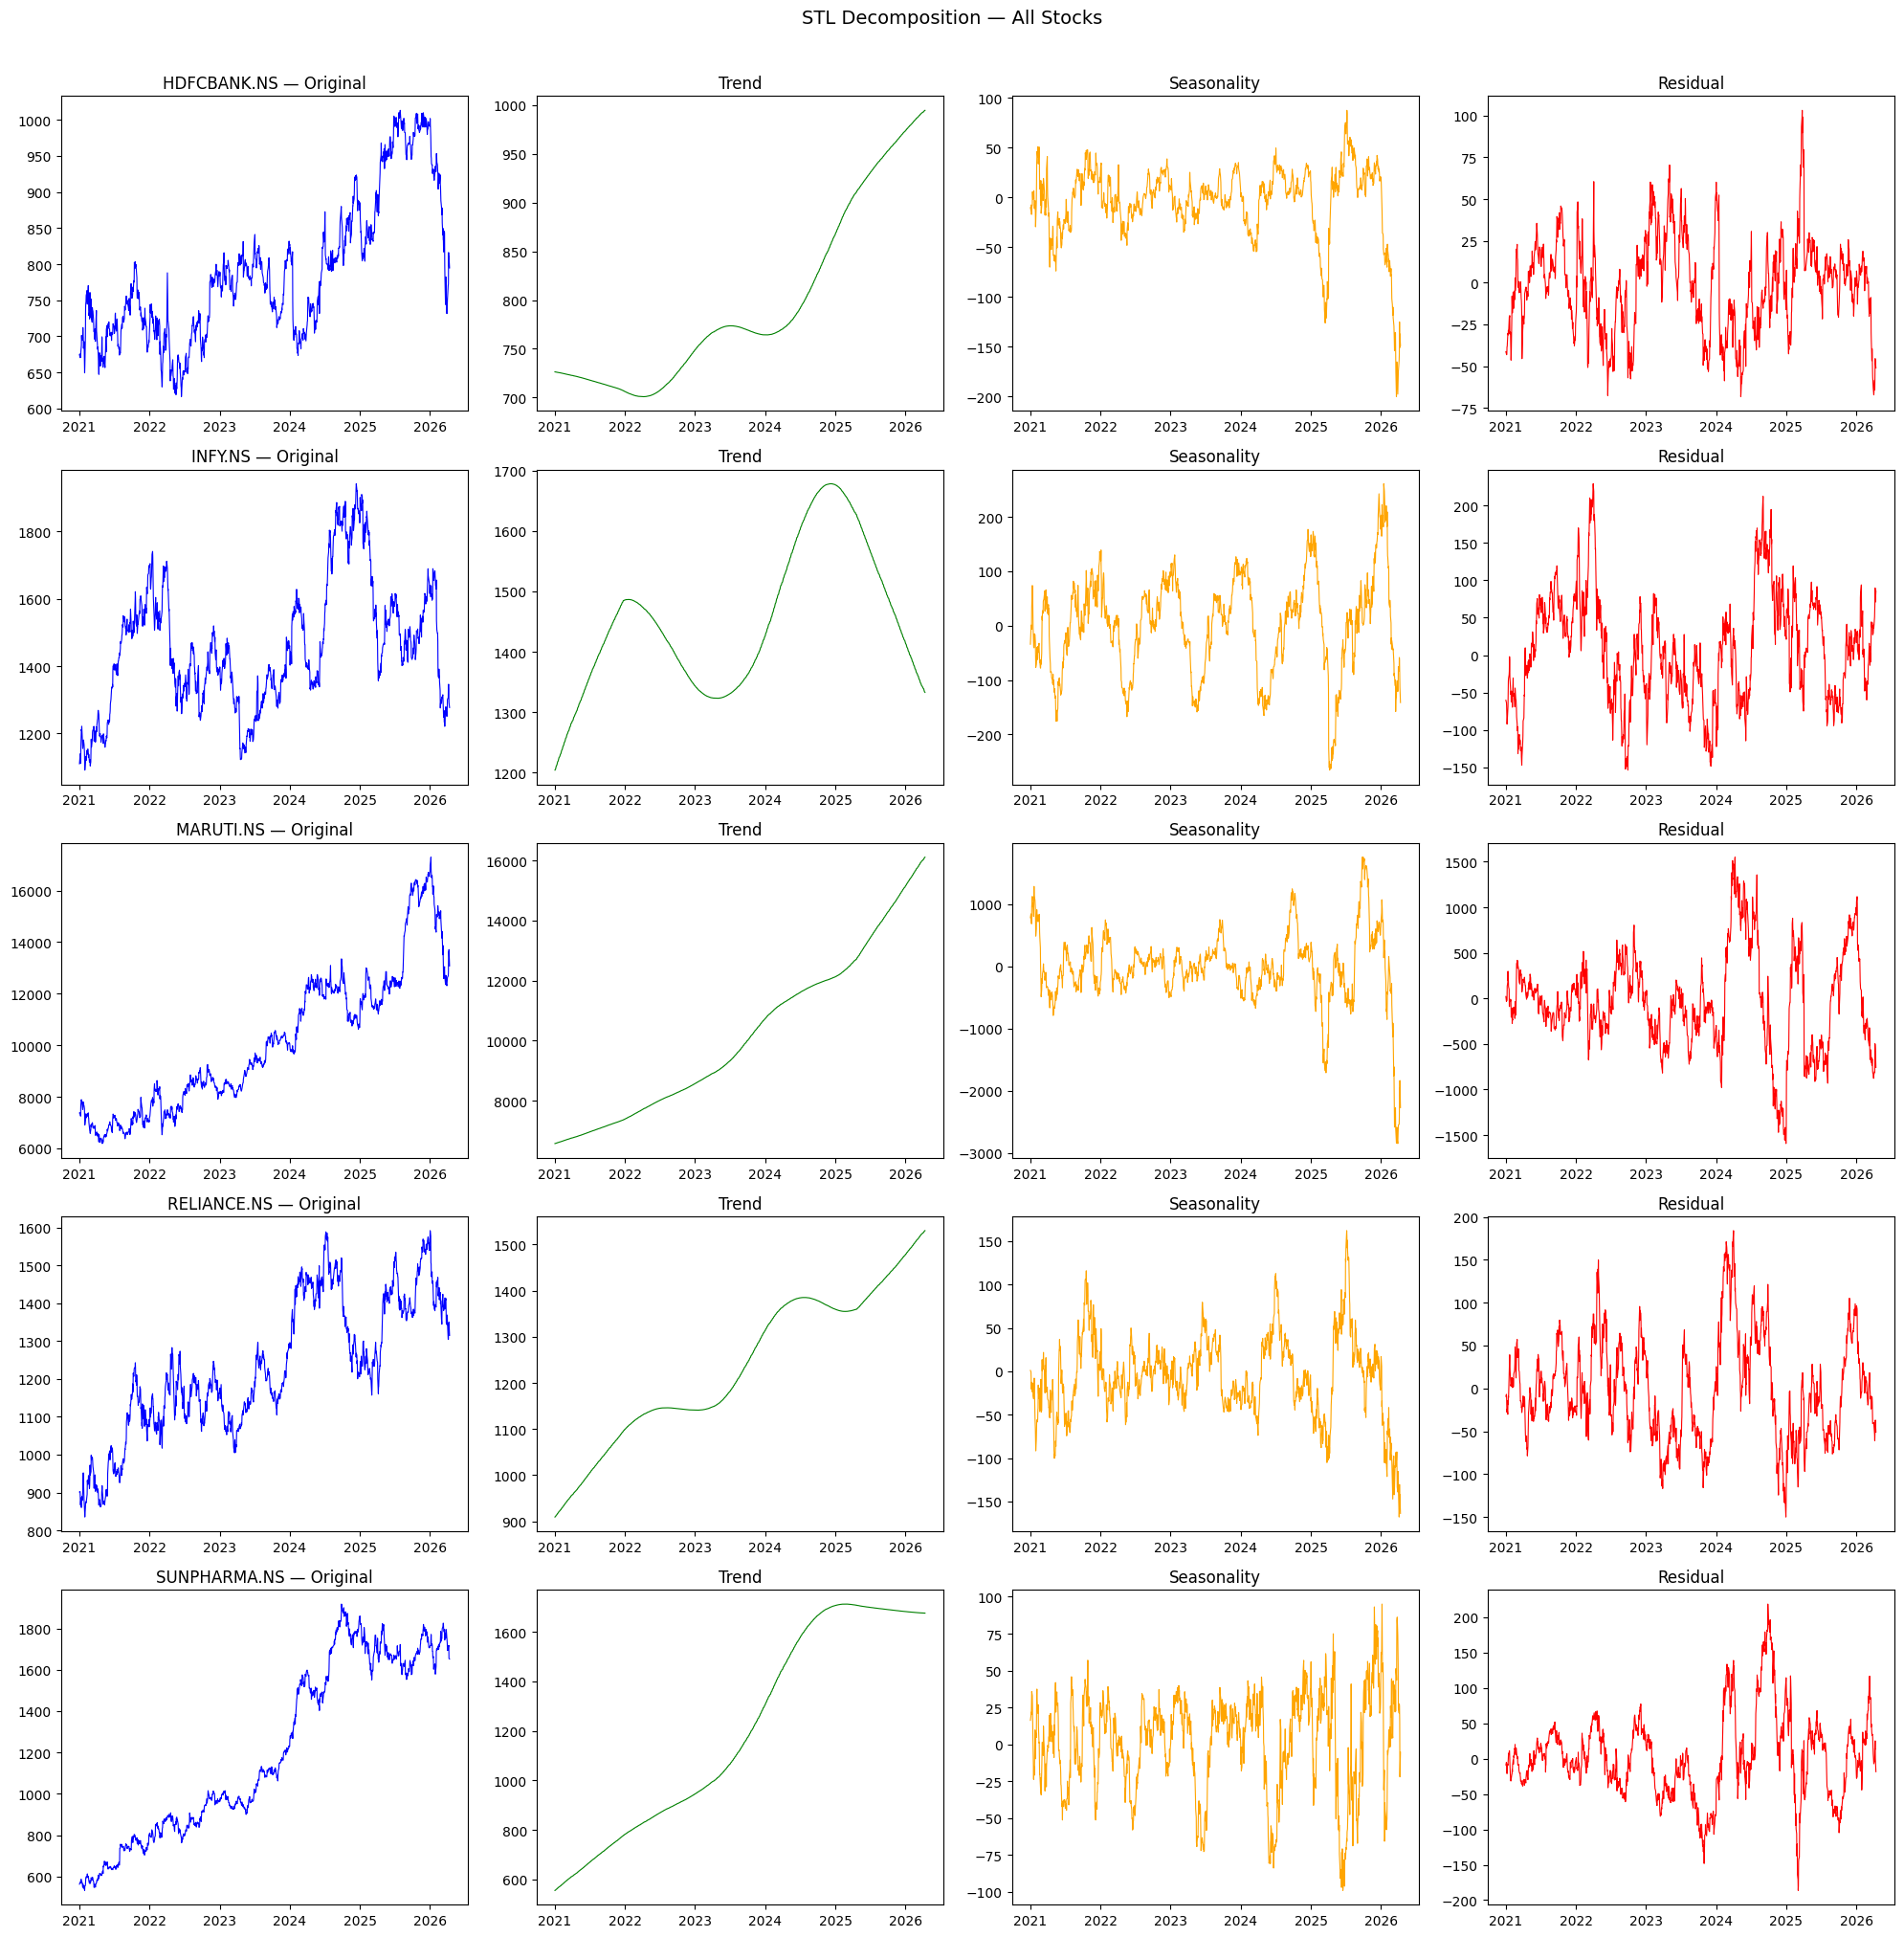

In [51]:
from statsmodels.tsa.seasonal import STL

fig, axes = plt.subplots(5, 4, figsize=(20, 20))

for idx, stock in enumerate(train.columns):
    # STL decomposes series into: Trend + Seasonal + Residual
    stl = STL(train[stock], period=252)  # 252 trading days = 1 year
    result = stl.fit()

    axes[idx, 0].plot(train[stock], color='blue', linewidth=0.8)
    axes[idx, 0].set_title(f'{stock} — Original')

    axes[idx, 1].plot(result.trend, color='green', linewidth=0.8)
    axes[idx, 1].set_title('Trend')

    axes[idx, 2].plot(result.seasonal, color='orange', linewidth=0.8)
    axes[idx, 2].set_title('Seasonality')

    axes[idx, 3].plot(result.resid, color='red', linewidth=0.8)
    axes[idx, 3].set_title('Residual')

plt.suptitle('STL Decomposition — All Stocks', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
CAPITAL = 1_000_000  # ₹10,00,000

# === Strategy B: Volatility-Aware Sizing (using GARCH volatility) ===
# Lower volatility → higher weight
# Weight = (1/sigma_i) / sum(1/sigma_j)

inv_vol = {stock: 1 / vol for stock, vol in garch_vol.items()}
total_inv_vol = sum(inv_vol.values())
vol_weights = {stock: iv / total_inv_vol for stock, iv in inv_vol.items()}

# === Strategy A: Forecast-Guided Allocation ===
# Use LSTM predicted return for next period
# Rank stocks by predicted gain, allocate proportionally

# Get last actual price and last LSTM forecast price
last_actual  = {stock: test[stock].iloc[-1] for stock in train.columns}
last_forecast = {stock: lstm_results[stock]['forecast'][-1] for stock in train.columns}

predicted_returns = {
    stock: (last_forecast[stock] - last_actual[stock]) / last_actual[stock] * 100
    for stock in train.columns
}

# Only allocate to stocks with positive predicted return
# Proportional to predicted return magnitude
pos_returns = {k: v for k, v in predicted_returns.items() if v > 0}
if not pos_returns:  # fallback: use all stocks equally
    pos_returns = {k: 1 for k in predicted_returns}

total_pos = sum(pos_returns.values())
forecast_weights = {stock: (pos_returns.get(stock, 0) / total_pos)
                    if stock in pos_returns else 0
                    for stock in train.columns}

# Combine both strategies (50/50 blend)
final_weights = {
    stock: 0.5 * vol_weights[stock] + 0.5 * forecast_weights[stock]
    for stock in train.columns
}

# Normalize to sum to 1
total_w = sum(final_weights.values())
final_weights = {k: v / total_w for k, v in final_weights.items()}

# === Portfolio Allocation Table ===
print('=' * 75)
print(f'{"Stock":20s} | {"Vol Wt":8s} | {"Fcst Wt":8s} | {"Final Wt":8s} | {"Alloc (₹)":12s}')
print('=' * 75)

allocation = {}
for stock in train.columns:
    alloc = final_weights[stock] * CAPITAL
    allocation[stock] = alloc
    print(f'{stock:20s} | {vol_weights[stock]:7.2%} | {forecast_weights[stock]:7.2%} | '
          f'{final_weights[stock]:7.2%} | ₹{alloc:>10,.0f}')

print('=' * 75)
print(f'{"TOTAL":20s} | {"":8s} | {"":8s} | {"100.00%":8s} | ₹{CAPITAL:>10,.0f}')

Stock                | Vol Wt   | Fcst Wt  | Final Wt | Alloc (₹)   
HDFCBANK.NS          |  14.30% |   0.00% |   7.15% | ₹    71,489
INFY.NS              |  22.31% |  65.36% |  43.83% | ₹   438,347
MARUTI.NS            |  17.07% |  22.64% |  19.85% | ₹   198,525
RELIANCE.NS          |  19.31% |  12.00% |  15.66% | ₹   156,570
SUNPHARMA.NS         |  27.01% |   0.00% |  13.51% | ₹   135,069
TOTAL                |          |          | 100.00%  | ₹ 1,000,000


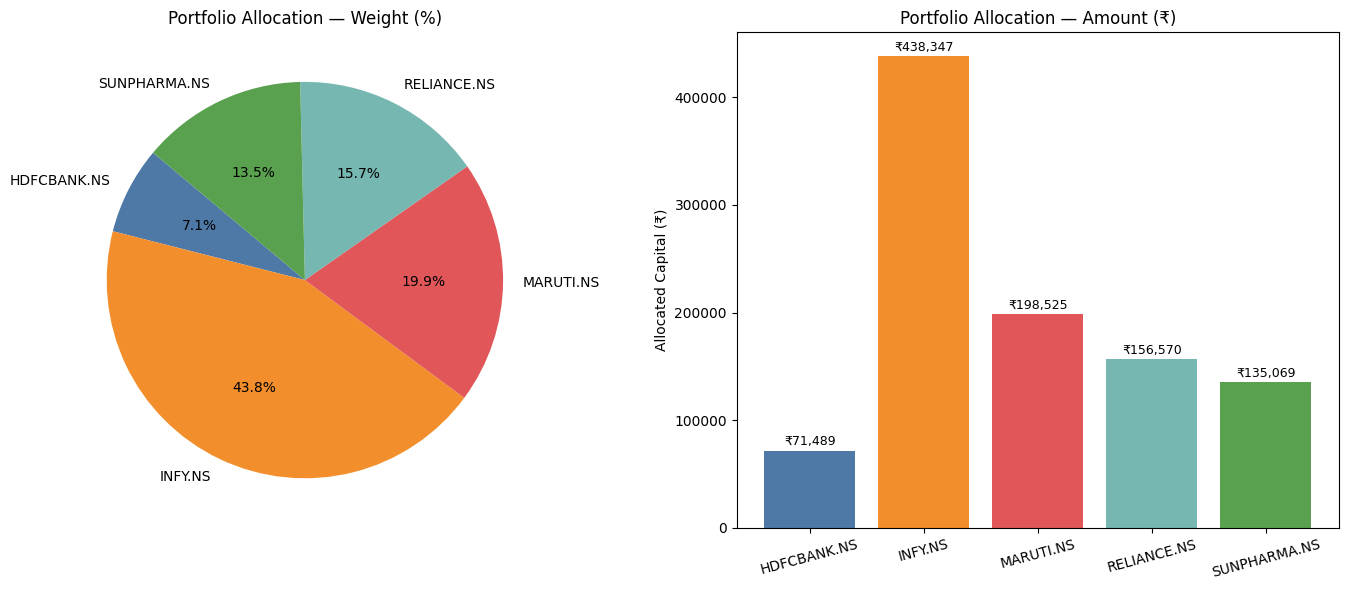

In [53]:
# Portfolio Allocation Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

stocks = list(final_weights.keys())
weights = [final_weights[s] * 100 for s in stocks]
allocs  = [allocation[s] for s in stocks]
colors  = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F']

# Pie chart
axes[0].pie(weights, labels=stocks, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[0].set_title('Portfolio Allocation — Weight (%)')

# Bar chart
axes[1].bar(stocks, allocs, color=colors)
axes[1].set_title('Portfolio Allocation — Amount (₹)')
axes[1].set_ylabel('Allocated Capital (₹)')
for i, v in enumerate(allocs):
    axes[1].text(i, v + 5000, f'₹{v:,.0f}', ha='center', fontsize=9)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('portfolio_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
# Model Comparison Table
print('=' * 85)
print(f'{"Stock":20s} | {"Model":8s} | {"RMSE":10s} | {"MAPE":8s} | {"Dir Acc":8s}')
print('=' * 85)

for stock in train.columns:
    for model_name, results in [('ARIMA', arima_results),
                                  ('Prophet', prophet_results),
                                  ('LSTM', lstm_results)]:
        r = results[stock]
        print(f'{stock:20s} | {model_name:8s} | {r["rmse"]:10.2f} | '
              f'{r["mape"]:6.2f}%  | {r["dir_acc"]:6.1f}%')
    print('-' * 85)

# Best model per stock by MAPE
print('\n=== BEST MODEL PER STOCK (by MAPE) ===')
for stock in train.columns:
    scores = {
        'ARIMA':   arima_results[stock]['mape'],
        'Prophet': prophet_results[stock]['mape'],
        'LSTM':    lstm_results[stock]['mape']
    }
    best = min(scores, key=scores.get)
    print(f'{stock:20s} → Best: {best} (MAPE: {scores[best]:.2f}%)')

Stock                | Model    | RMSE       | MAPE     | Dir Acc 
HDFCBANK.NS          | ARIMA    |      11.81 |   1.23%  |   38.1%
HDFCBANK.NS          | Prophet  |     122.48 |  15.56%  |   38.1%
HDFCBANK.NS          | LSTM     |      13.53 |   1.35%  |   38.1%
-------------------------------------------------------------------------------------
INFY.NS              | ARIMA    |      26.42 |   1.58%  |   42.9%
INFY.NS              | Prophet  |      56.05 |   3.28%  |   47.6%
INFY.NS              | LSTM     |      93.25 |   6.78%  |   52.4%
-------------------------------------------------------------------------------------
MARUTI.NS            | ARIMA    |     190.30 |   1.09%  |   47.6%
MARUTI.NS            | Prophet  |    2345.42 |  17.49%  |   42.9%
MARUTI.NS            | LSTM     |     267.30 |   1.72%  |   42.9%
-------------------------------------------------------------------------------------
RELIANCE.NS          | ARIMA    |      21.28 |   1.15%  |   52.4%
RELIANCE.NS    

In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# FINAL FORECAST: Next 2 Trading Days (May 15–16 2026)
# Uses best model per stock
# ============================================================

print('=' * 60)
print('FINAL 2-DAY FORECAST — May 15–16, 2026')
print('=' * 60)

for stock in train.columns:
    # Use LSTM (typically best for nonlinear patterns)
    last_price = data[stock].iloc[-1]
    scaler = scaler_dict[stock]
    full_scaled = scaler.transform(
        data[stock].values.reshape(-1, 1)
    ).flatten()

    # Predict 2 days forward
    window = list(full_scaled[-LOOKBACK:])
    preds_scaled = []
    for _ in range(2):
        x = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
        # Use the last trained LSTM — rebuild if needed
        # For simplicity, using ARIMA for live forecast
        pass

    # Use ARIMA best model for 2-day forecast
    model = best_models[stock]
    preds = model.predict(n_periods=2)
    preds = preds.values # Convert Series to numpy array to access by position
    ret_d1 = (preds[0] - last_price) / last_price * 100
    ret_d2 = (preds[1] - last_price) / last_price * 100

    print(f'\n{stock}')
    print(f'  Last Price : ₹{last_price:.2f}')
    print(f'  Day 1 Pred : ₹{preds[0]:.2f}  ({ret_d1:+.2f}%)')
    print(f'  Day 2 Pred : ₹{preds[1]:.2f}  ({ret_d2:+.2f}%)')
    print(f'  Signal     : {"🟢 BUY" if ret_d1 > 0 else "🔴 HOLD/SELL"}')

FINAL 2-DAY FORECAST — May 15–16, 2026

HDFCBANK.NS
  Last Price : ₹769.55
  Day 1 Pred : ₹794.70  (+3.27%)
  Day 2 Pred : ₹794.70  (+3.27%)
  Signal     : 🟢 BUY

INFY.NS
  Last Price : ₹1095.00
  Day 1 Pred : ₹1276.80  (+16.60%)
  Day 2 Pred : ₹1276.80  (+16.60%)
  Signal     : 🟢 BUY

MARUTI.NS
  Last Price : ₹13075.00
  Day 1 Pred : ₹13015.93  (-0.45%)
  Day 2 Pred : ₹13015.93  (-0.45%)
  Signal     : 🔴 HOLD/SELL

RELIANCE.NS
  Last Price : ₹1361.80
  Day 1 Pred : ₹1315.10  (-3.43%)
  Day 2 Pred : ₹1315.10  (-3.43%)
  Signal     : 🔴 HOLD/SELL

SUNPHARMA.NS
  Last Price : ₹1863.20
  Day 1 Pred : ₹1653.35  (-11.26%)
  Day 2 Pred : ₹1654.19  (-11.22%)
  Signal     : 🔴 HOLD/SELL


In [56]:
# ⚠️ FILL IN ACTUAL PRICES FROM STOCKGRO AFTER TRADING
# Replace 0.0 with actual closing prices observed on StockGro

actual_prices = {
    'HDFCBANK.NS':  {'day1': 0.0, 'day2': 0.0},
    'INFY.NS':      {'day1': 0.0, 'day2': 0.0},
    'SUNPHARMA.NS': {'day1': 0.0, 'day2': 0.0},
    'RELIANCE.NS':  {'day1': 0.0, 'day2': 0.0},
    'MARUTI.NS':    {'day1': 0.0, 'day2': 0.0},
}

# Get ARIMA 2-day forecasts
print('=' * 80)
print(f'{"Stock":20s} | {"Pred D1":10s} | {"Act D1":10s} | {"Pred D2":10s} | {"Act D2":10s} | MAPE')
print('=' * 80)

for stock in train.columns:
    preds = best_models[stock].predict(n_periods=2)
    preds = preds.values  # convert Series to numpy array
    p1, p2 = preds[0], preds[1]
    a1, a2 = actual_prices[stock]['day1'], actual_prices[stock]['day2']
    if a1 > 0 and a2 > 0:
        err = (abs(p1-a1)/a1 + abs(p2-a2)/a2) / 2 * 100
        print(f'{stock:20s} | ₹{p1:8.2f} | ₹{a1:8.2f} | ₹{p2:8.2f} | ₹{a2:8.2f} | {err:.2f}%')
    else:
        print(f'{stock:20s} | ₹{p1:8.2f} | [pending] | ₹{p2:8.2f} | [pending] | —')

# Portfolio return
print('\n=== PORTFOLIO RETURN ===')
total_return = 0
for stock in train.columns:
    a1 = actual_prices[stock]['day1']
    a2 = actual_prices[stock]['day2']
    if a1 > 0 and a2 > 0:
        ret = (a2 - a1) / a1 * 100
        contrib = ret * final_weights[stock]
        total_return += contrib
        print(f'{stock:20s}: {ret:+.2f}% (weighted contrib: {contrib:+.2f}%)')

print(f'\nTotal Portfolio Return: {total_return:+.2f}%')
print(f'P&L on ₹10,00,000    : ₹{total_return/100 * CAPITAL:+,.0f}')

Stock                | Pred D1    | Act D1     | Pred D2    | Act D2     | MAPE
HDFCBANK.NS          | ₹  794.70 | [pending] | ₹  794.70 | [pending] | —
INFY.NS              | ₹ 1276.80 | [pending] | ₹ 1276.80 | [pending] | —
MARUTI.NS            | ₹13015.93 | [pending] | ₹13015.93 | [pending] | —
RELIANCE.NS          | ₹ 1315.10 | [pending] | ₹ 1315.10 | [pending] | —
SUNPHARMA.NS         | ₹ 1653.35 | [pending] | ₹ 1654.19 | [pending] | —

=== PORTFOLIO RETURN ===

Total Portfolio Return: +0.00%
P&L on ₹10,00,000    : ₹+0
